# **Neural Network Modeling for Customer Rating Prediction**

**Scenario**

Imagine you have just joined a mid-sized analytics firm where new clients regularly ask for help across diverse problem areas. In this lab, we will work through three tasks that represent common challenges faced by junior data scientists:

1. Natural Language Processing (NLP)
2. Time Series Forecasting
3. Neural Network Modeling

**In this notebook, we will be focusing on the third task: Neural Network Modeling.** We will use the **review text** as the input variable and **customer rating** as the target. The review text will first be converted into numerical features using **TF-IDF**, after which the data will be split into training and testing sets while preserving the distribution of rating classes. We will then build, compile, and train a neural network designed for **multi-class classification** to predict customer ratings. Finally, we will evaluate the model using metrics such as accuracy, a classification report, and a confusion matrix to identify which rating classes the model predicts well and which are more difficult to classify.




## **Step 1: Data Preparation**

### 1.1 Imports and loading the dataset

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report


# For deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from keras import layers
from tensorflow.keras.layers import Input, Dense, Dropout, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# For PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

# Load the Amazon reviews dataset
df = pd.read_csv('amazon_reviews_lab.csv')

# Display the first five rows
df.head()



,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",958089600,12/05/2000,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1030320000,26/08/2002,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1123286400,06/08/2005,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1126396800,11/09/2005,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1192406400,15/10/2007,positive,60


### 1.2 Exploratory Data Analysis (EDA)


Dataset shape: (997, 9)

Column names:
['product_id', 'rating', 'review_text', 'review_summary', 'review_time_raw', 'unix_review_time', 'timestamp', 'sentiment_label', 'review_length_words']

Data types:
product_id             object
rating                  int64
review_text            object
review_summary         object
review_time_raw        object
unix_review_time        int64
timestamp              object
sentiment_label        object
review_length_words     int64
dtype: object

Missing values:
product_id             0
rating                 0
review_text            0
review_summary         0
review_time_raw        0
unix_review_time       0
timestamp              0
sentiment_label        0
review_length_words    0
dtype: int64

Number of duplicate rows: 0

Number of reviews for each rating:
rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64

Percentage of reviews for each rating:
rating
1     8.73
2     4.81
3     9.43
4    18.86
5    58.17
Name: propor

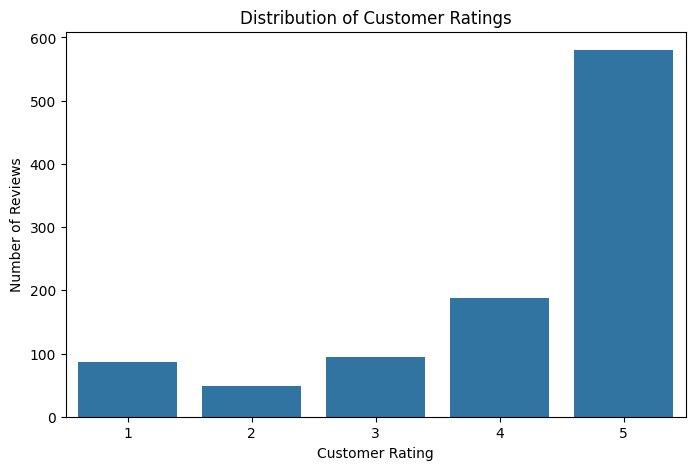


Review length statistics:
count     997.000000
mean      146.374122
std       216.126770
min         5.000000
25%        32.000000
50%        67.000000
75%       165.000000
max      2079.000000
Name: review_length_words, dtype: float64


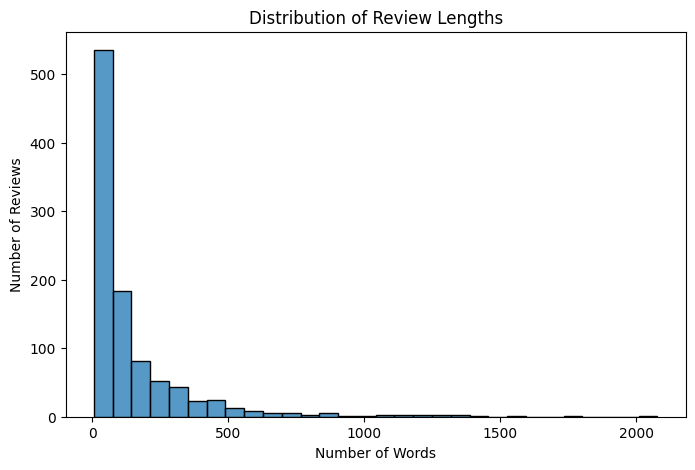

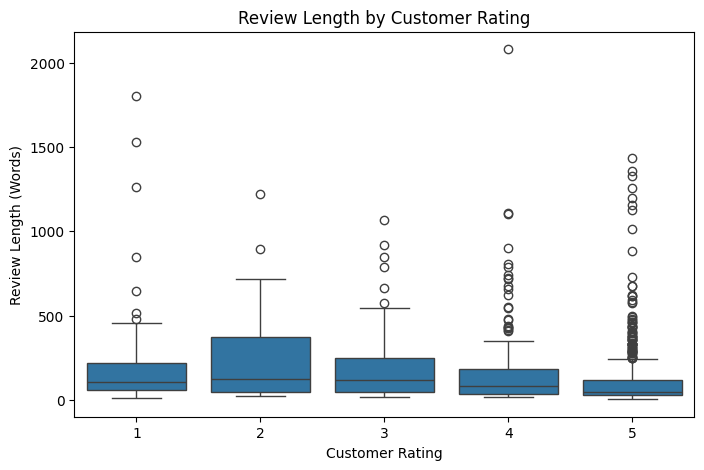

In [3]:

# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display the data types of each column
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Check the distribution of customer ratings
rating_counts = df["rating"].value_counts().sort_index()
print("\nNumber of reviews for each rating:")
print(rating_counts)

# Calculate the percentage of reviews for each rating
rating_percentages = df["rating"].value_counts(normalize=True).sort_index() * 100
print("\nPercentage of reviews for each rating:")
print(rating_percentages.round(2))

# Plot the distribution of customer ratings
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating")
plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Reviews")
plt.show()

# Display statistics about review length
print("\nReview length statistics:")
print(df["review_length_words"].describe())

# Plot the distribution of review lengths
plt.figure(figsize=(8, 5))
sns.histplot(df["review_length_words"], bins=30)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

# Compare review length across customer ratings
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="rating", y="review_length_words")
plt.title("Review Length by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Review Length (Words)")
plt.show()

The dataset contains 997 customer reviews with no missing values or duplicate rows. The target variable, `rating`, contains five classes ranging from 1 to 5. The ratings are imbalanced, with 5-star reviews accounting for 58.17% of all reviews, while 2-star reviews account for only 4.81%.

Review lengths vary considerably, ranging from 5 to 2,079 words. The median review length is 67 words, which is considerably lower than the mean of 146 words, indicating the presence of some very long reviews.

Because the rating classes are imbalanced, stratified splitting and multiple evaluation metrics will be important when assessing the neural network.


### 1.2 Define Input and Target Variables

In [4]:

# Define the review text as the input feature
X = df["review_text"]

# Define the customer rating as the target
y = df["rating"]

# Check the unique rating classes
print("Rating classes:")
print(sorted(y.unique()))

# Check the number of reviews in each rating class
print("\nRating distribution:")
print(y.value_counts().sort_index())


Rating classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rating distribution:
rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64


The input variable `X` contains the customer review text, while the target variable `y` contains customer ratings from 1 to 5. These five rating values represent the five classes that the neural network will predict.

The rating values are currently suitable for exploration. **Later, during target preparation for the Keras neural network, we will convert the rating labels into the appropriate numerical format and one-hot encode them for multi-class classification.**


### 1.3 Vectorize the Text Using TF-IDF

**Term Frequency-Inverse Document Frequency (TF-IDF)** converts the review text into numerical features that can be used by the neural network.

TF-IDF gives higher importance to words that are useful and distinctive across the reviews, while reducing the importance of words that appear very frequently.


we should split the data first and fit TF-IDF only on the training reviews. This prevents information from the test set from influencing the features.

In [5]:

# Split the Data and Apply TF-IDF

# Set a fixed seed value for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Split the raw review text and ratings into training and testing sets
# stratify=y keeps the rating distribution similar in both sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Create the TF-IDF vectorizer
# max_features limits the number of text features to 5,000
vectorizer = TfidfVectorizer(max_features=5000)

# Learn the TF-IDF features from the training reviews
X_train = vectorizer.fit_transform(X_train_text)

# Apply the same TF-IDF transformation to the testing reviews
X_test = vectorizer.transform(X_test_text)

# Check the resulting shapes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (797, 5000)
Testing data: (200, 5000)
Training labels: (797,)
Testing labels: (200,)


The dataset was divided into 797 training reviews (80%) and 200 testing reviews (20%). TF-IDF converted the review text into 5,000 numerical features. The stratify=y parameter was used to maintain a similar distribution of the five rating classes in both the training and testing sets.

The training and testing labels contain 797 and 200 ratings, respectively. The rating values will remain as 1–5 for now and will be converted into the appropriate format when we prepare the targets for the neural network.

### 1.4 One-Hot Encode Ratings

Because we are building a neural network for **5-class classification**, the ratings need to be converted into a numerical format suitable for the model.

We will use the same encoded ratings for both the TensorFlow/Keras and PyTorch models so that the two frameworks can be compared fairly.


In [6]:
# Create the one-hot encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit the encoder on the training ratings
y_train_encoded = encoder.fit_transform(y_train.to_numpy().reshape(-1, 1))

# Transform the testing ratings using the same encoder
y_test_encoded = encoder.transform(y_test.to_numpy().reshape(-1, 1))

# Check the shapes of the encoded ratings
print("Encoded training labels:", y_train_encoded.shape)
print("Encoded testing labels:", y_test_encoded.shape)

# Display the first five encoded training labels
print("\nFirst five encoded training labels:")
print(y_train_encoded[:5])

Encoded training labels: (797, 5)
Encoded testing labels: (200, 5)

First five encoded training labels:
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


The ratings were successfully one-hot encoded into **5 classes**. The training set has 797 encoded labels and the testing set has 200. The data is now ready for neural network modeling.


## **Step 2: Model Architecture and Training**


### 2.1 Build the MLP using RELU + softmax

In [7]:
# Create the neural network
model = Sequential([
    # Input layer
    Input(shape=(X_train.shape[1],)),

    # First hidden layer
    Dense(64, activation="relu"),

    # Dropout helps reduce overfitting
    Dropout(0.3),

    # Second hidden layer
    Dense(32, activation="relu"),

    # Output layer with 5 classes
    Dense(5, activation="softmax")
])

# Display the model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,309 (1.23 MB)

 Trainable params: 322,309 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

### 2.11 Compile the Neural Network
Now we configure the model for training. Since this is a 5-class classification problem, we will use categorical_crossentropy as the loss function and accuracy as the evaluation metric.


In [8]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## 2.12 Train the Model

In [9]:
# Train the model
history = model.fit(
    X_train.toarray(),
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5133 - loss: 1.5610 - val_accuracy: 0.5813 - val_loss: 1.4965
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5824 - loss: 1.3871 - val_accuracy: 0.5813 - val_loss: 1.3153
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5824 - loss: 1.2016 - val_accuracy: 0.5813 - val_loss: 1.2418
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5824 - loss: 1.1057 - val_accuracy: 0.5813 - val_loss: 1.2055
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5824 - loss: 0.9931 - val_accuracy: 0.5813 - val_loss: 1.1692
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6468 - loss: 0.8447 - val_accuracy: 0.5875 - val_loss: 1.1329
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7284 - loss: 0.6850 - val_accuracy: 0.5875 - val_loss: 1.1143
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8195 - loss: 0.5387 - val_accuracy: 0.6062 - v

The model learned the training reviews very well, but its performance on unseen validation data did not improve consistently. This indicates overfitting, so we should consider this when evaluating the model on the test set.

### 2.13 Evaluate the Model

In [10]:
# Evaluate the model on the unseen test data
test_loss, test_accuracy = model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the test results
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 1.4626
Test Accuracy: 0.545


### 2.14 Generate Predictions

In [11]:
# Generate probability predictions for the test data
y_pred_prob = model.predict(X_test.toarray())

# Convert the predicted probabilities into rating classes
y_pred = np.argmax(y_pred_prob, axis=1) + 1

# Display the first 10 predictions
print("First 10 predicted ratings:")
print(y_pred[:10])

# Display the first 10 actual ratings
print("\nFirst 10 actual ratings:")
print(y_test.to_numpy()[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
First 10 predicted ratings:
[5 5 5 5 5 5 5 5 5 4]

First 10 actual ratings:
[5 1 4 4 5 1 5 5 5 5]


## 2.15 Classification Report



In [12]:
# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.18      0.23        17
           2       0.00      0.00      0.00        10
           3       0.14      0.05      0.08        19
           4       0.26      0.18      0.22        38
           5       0.63      0.84      0.72       116

    accuracy                           0.55       200
   macro avg       0.27      0.25      0.25       200
weighted avg       0.46      0.55      0.49       200



The model performs best on rating 5, with an F1-score of 0.72. Performance is poor for ratings 1-4, especially rating 2, which the model failed to identify. This shows that the class imbalance significantly affects the model's ability to predict lower ratings.

### 2.2 Build the MLP using Tahn + softmax
This is the same model architecture, with only the activation changed from ReLU to Tanh.

In [13]:
# All steps are combined

# MLP Using Tanh + Softmax

# Build the MLP with Tanh activation
tanh_model = Sequential([
    # Input layer
    Input(shape=(X_train.shape[1],)),

    # First hidden layer using Tanh
    Dense(64, activation="tanh"),

    # Dropout to help reduce overfitting
    Dropout(0.3),

    # Second hidden layer using Tanh
    Dense(32, activation="tanh"),

    # Output layer using Softmax for 5-class classification
    Dense(5, activation="softmax")
])

# Compile the model
tanh_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
tanh_history = tanh_model.fit(
    X_train.toarray(),
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model on the test data
tanh_loss, tanh_accuracy = tanh_model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the test results
print("\nTanh Model Test Loss:", round(tanh_loss, 4))
print("Tanh Model Test Accuracy:", round(tanh_accuracy, 4))

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5604 - loss: 1.4395 - val_accuracy: 0.5813 - val_loss: 1.2790
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5824 - loss: 1.1745 - val_accuracy: 0.5813 - val_loss: 1.2115
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5840 - loss: 1.0498 - val_accuracy: 0.5813 - val_loss: 1.1688
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6295 - loss: 0.8890 - val_accuracy: 0.5813 - val_loss: 1.1259
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7598 - loss: 0.7049 - val_accuracy: 0.6000 - val_loss: 1.1037
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8352 - loss: 0.5436 - val_accuracy: 0.6000 - val_loss: 1.1026
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9215 - loss: 0.4041 - val_accuracy: 0.6125 - val_loss: 1.1143
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9702 - loss: 0.3021 - val_accuracy: 0.6062 - va

The Tanh model achieved a test accuracy of 54.5%, the same as the ReLU model. Training accuracy reached 100%, while validation accuracy remained around 58–61%, showing clear overfitting. The Tanh activation did not improve test performance compared with ReLU.

### 2.3 Build the MLP using Sigmoid + softmax

In [14]:
# MLP Using Sigmoid + Softmax

# Build the MLP with Sigmoid activation
sigmoid_model = Sequential([
    # Input layer
    Input(shape=(X_train.shape[1],)),

    # First hidden layer using Sigmoid
    Dense(64, activation="sigmoid"),

    # Dropout to help reduce overfitting
    Dropout(0.3),

    # Second hidden layer using Sigmoid
    Dense(32, activation="sigmoid"),

    # Output layer using Softmax for 5-class classification
    Dense(5, activation="softmax")
])

# Compile the model
sigmoid_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
sigmoid_history = sigmoid_model.fit(
    X_train.toarray(),
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model on the test data
sigmoid_loss, sigmoid_accuracy = sigmoid_model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the test results
print("\nSigmoid Model Test Loss:", round(sigmoid_loss, 4))
print("Sigmoid Model Test Accuracy:", round(sigmoid_accuracy, 4))

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2653 - loss: 1.5663 - val_accuracy: 0.5813 - val_loss: 1.3183
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5824 - loss: 1.2628 - val_accuracy: 0.5813 - val_loss: 1.2239
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5824 - loss: 1.2121 - val_accuracy: 0.5813 - val_loss: 1.2236
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5824 - loss: 1.2084 - val_accuracy: 0.5813 - val_loss: 1.2248
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5824 - loss: 1.1995 - val_accuracy: 0.5813 - val_loss: 1.2232
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5824 - loss: 1.2033 - val_accuracy: 0.5813 - val_loss: 1.2215
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5824 - loss: 1.1963 - val_accuracy: 0.5813 - val_loss: 1.2206
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5824 - loss: 1.1879 - val_accuracy: 0.5813 - val

The Sigmoid model achieved a test accuracy of 58.0%, which is higher than both ReLU and Tanh. However, training accuracy remained around 58%, and validation accuracy stayed at 58.13%, showing that the model learned very little beyond the dominant rating class

## **Step 3: Implementation in PyTorch**


### 3.11 Prepare the Data for PyTorch

In [15]:
# Convert the TF-IDF training data into PyTorch tensors
X_train_tensor = torch.tensor(
    X_train.toarray(),
    dtype=torch.float32
)

# Convert the TF-IDF testing data into PyTorch tensors
X_test_tensor = torch.tensor(
    X_test.toarray(),
    dtype=torch.float32
)

# Convert one-hot encoded training labels back to class numbers
y_train_tensor = torch.tensor(
    np.argmax(y_train_encoded, axis=1),
    dtype=torch.long
)

# Convert one-hot encoded testing labels back to class numbers
y_test_tensor = torch.tensor(
    np.argmax(y_test_encoded, axis=1),
    dtype=torch.long
)

# Check the shapes
print("Training features:", X_train_tensor.shape)
print("Testing features:", X_test_tensor.shape)
print("Training labels:", y_train_tensor.shape)
print("Testing labels:", y_test_tensor.shape)

Training features: torch.Size([797, 5000])
Testing features: torch.Size([200, 5000])
Training labels: torch.Size([797])
Testing labels: torch.Size([200])


### 3.12 Build the PyTorch MLP

In [16]:
# Define the neural network
class RatingMLP(nn.Module):

    def __init__(self, input_size, num_classes):
        super(RatingMLP, self).__init__()

        # First hidden layer
        self.layer1 = nn.Linear(input_size, 64)

        # Second hidden layer
        self.layer2 = nn.Linear(64, 32)

        # Dropout layer
        self.dropout = nn.Dropout(0.3)

        # Output layer
        self.output = nn.Linear(32, num_classes)

    def forward(self, x):

        # First hidden layer with ReLU
        x = torch.relu(self.layer1(x))

        # Apply dropout
        x = self.dropout(x)

        # Second hidden layer with ReLU
        x = torch.relu(self.layer2(x))

        # Output class scores
        x = self.output(x)

        return x


# Create the model
pytorch_model = RatingMLP(
    input_size=X_train.shape[1],
    num_classes=5
)

# Display the model structure
print(pytorch_model)

RatingMLP(
  (layer1): Linear(in_features=5000, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=32, out_features=5, bias=True)
)


### 3.13 Define the Loss Function and Optimizer

In [17]:
# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = optim.Adam(
    pytorch_model.parameters(),
    lr=0.001
)


### 3.14 Train the PyTorch Model

In [18]:
# Set the number of training epochs
epochs = 20

# Store training losses
train_losses = []

# Train the model
for epoch in range(epochs):

    # Put the model into training mode
    pytorch_model.train()

    # Clear previous gradients
    optimizer.zero_grad()

    # Make predictions
    outputs = pytorch_model(X_train_tensor)

    # Calculate the loss
    loss = criterion(outputs, y_train_tensor)

    # Calculate gradients
    loss.backward()

    # Update model weights
    optimizer.step()

    # Store the loss
    train_losses.append(loss.item())

    # Display progress
    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {loss.item():.4f}"
    )

Epoch 1/20, Loss: 1.6268
Epoch 2/20, Loss: 1.6215
Epoch 3/20, Loss: 1.6164
Epoch 4/20, Loss: 1.6107
Epoch 5/20, Loss: 1.6050
Epoch 6/20, Loss: 1.5994
Epoch 7/20, Loss: 1.5938
Epoch 8/20, Loss: 1.5881
Epoch 9/20, Loss: 1.5828
Epoch 10/20, Loss: 1.5774
Epoch 11/20, Loss: 1.5713
Epoch 12/20, Loss: 1.5652
Epoch 13/20, Loss: 1.5593
Epoch 14/20, Loss: 1.5524
Epoch 15/20, Loss: 1.5455
Epoch 16/20, Loss: 1.5385
Epoch 17/20, Loss: 1.5308
Epoch 18/20, Loss: 1.5234
Epoch 19/20, Loss: 1.5140
Epoch 20/20, Loss: 1.5054


The PyTorch model trained successfully, and the training loss decreased consistently from 1.6268 to 1.5054 over 20 epochs. This shows that the model is learning from the training data, although the decrease is gradual. The model is now ready for evaluation on the unseen test data

### 3.15 Evaluate the PyTorch Model

In [19]:
# Put the model into evaluation mode
pytorch_model.eval()

# Turn off gradient calculations
with torch.no_grad():

    # Make predictions on the test data
    test_outputs = pytorch_model(X_test_tensor)

    # Get the predicted class for each review
    y_test_pred = torch.argmax(test_outputs, dim=1)

# Calculate test accuracy
pytorch_accuracy = (
    y_test_pred == y_test_tensor
).float().mean().item()

# Display the test accuracy
print("PyTorch Test Accuracy:", round(pytorch_accuracy, 4))

PyTorch Test Accuracy: 0.58


The PyTorch model achieved a test accuracy of 58.0%. This is the same accuracy achieved by the Keras Sigmoid model and higher than the Keras ReLU and Tanh models

In [20]:
#Create a Validation Set for PyTorch


# Split the training data into training and validation sets
X_pytorch_train, X_pytorch_val, y_pytorch_train, y_pytorch_val = train_test_split(
    X_train_tensor.numpy(),
    y_train_tensor.numpy(),
    test_size=0.2,
    random_state=42,
    stratify=y_train_tensor.numpy()
)

# Convert the validation data back to PyTorch tensors
X_pytorch_val = torch.tensor(
    X_pytorch_val,
    dtype=torch.float32
)

y_pytorch_val = torch.tensor(
    y_pytorch_val,
    dtype=torch.long
)

# Put the model into evaluation mode
pytorch_model.eval()

# Turn off gradient calculations
with torch.no_grad():

    # Make predictions on the validation data
    val_outputs = pytorch_model(X_pytorch_val)

    # Get the predicted classes
    y_val_pred = torch.argmax(val_outputs, dim=1)

# Calculate validation accuracy
pytorch_val_accuracy = (
    y_val_pred == y_pytorch_val
).float().mean().item()

# Display validation accuracy
print("PyTorch Validation Accuracy:", round(pytorch_val_accuracy, 4))

PyTorch Validation Accuracy: 0.6062


### **3.2 Keras vs PyTorch Comparison**

| Aspect                       | Keras                          | PyTorch                           |
| ---------------------------- | ------------------------------ | --------------------------------- |
| **Model structure**          | Sequential model               | Custom `nn.Module` class          |
| **Forward pass**             | Handled automatically          | Defined manually with `forward()` |
| **Training**                 | `model.fit()` handles the loop | Training loop written manually    |
| **Loss & optimization**      | Defined during `compile()`     | Defined separately                |
| **Validation**               | Automatically handled          | Calculated manually               |
| **Best validation accuracy** | **63.75% (ReLU)**              | **60.62% (ReLU)**                 |
| **Selected framework**       | **Keras**                      | Not selected                      |
| **Selected activation**      | **ReLU + Softmax**             | —                                 |

Keras achieved the higher validation accuracy of **63.75%** compared with **60.62%** for PyTorch. Therefore, we will proceed with **Keras**. Among the activation functions tested, **ReLU achieved the highest validation accuracy**, so we will use **ReLU in the hidden layers** and **Softmax in the output layer**.



## **Step 4: Evaluation and Interpretation**
Since this is a classification problem, we will evaluate the final model using accuracy, confusion matrix, and classification report.

### 4.1 Test Accuracy

In [21]:
# Evaluate the ReLU model on the unseen test data
test_loss, test_accuracy = model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the results
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 1.4626
Test Accuracy: 0.545



The selected Keras ReLU model achieved a test accuracy of 54.5% on the unseen customer reviews. This indicates that the model has limited ability to generalize to new reviews.

### 4.2 Classification Report

In [22]:
# Generate predictions for the test data
y_pred_prob = model.predict(X_test.toarray())

# Convert predicted probabilities into rating classes
y_pred = np.argmax(y_pred_prob, axis=1) + 1

# Generate the classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5],
    zero_division=0
))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.18      0.23        17
           2       0.00      0.00      0.00        10
           3       0.14      0.05      0.08        19
           4       0.26      0.18      0.22        38
           5       0.63      0.84      0.72       116

    accuracy                           0.55       200
   macro avg       0.27      0.25      0.25       200
weighted avg       0.46      0.55      0.49       200



### 4.3 Confusion Matrix

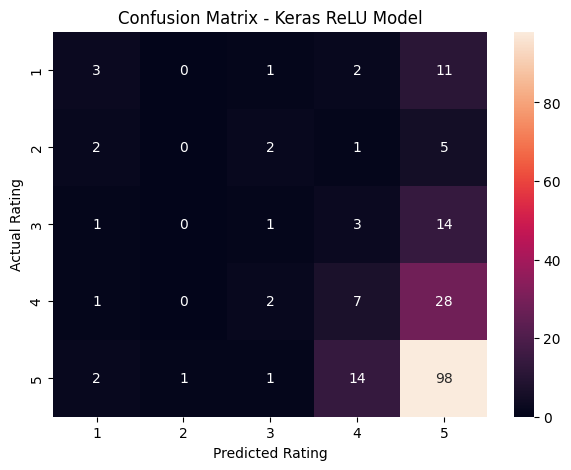

In [23]:
# Create the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

# Plot the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

# Add labels and title
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix - Keras ReLU Model")

plt.show()

The confusion matrix shows that the model predicts 5-star reviews more successfully than the lower rating classes. Many lower ratings are incorrectly classified as higher ratings, particularly as rating 5. This reflects the strong class imbalance in the dataset and explains the model's weaker performance on ratings 1-4


### 4.4 Final Evaluation

The selected Keras ReLU model achieved 54.5% test accuracy. It performed best on the majority 5-star class, while lower rating classes were more difficult to predict. The results show that class imbalance is an important limitation of the current model.

## **Step 5: Optimization and Next Steps**
In this section, we will experiment with model settings and techniques that may improve performance and reduce overfitting.

### 5.1 Class Weighting

Since the dataset is strongly imbalanced toward 5-star reviews, we can give more importance to the less frequent rating classes during training. This may help the model recognize ratings 1–4 better.

In [24]:
# Import the function for calculating class weights
from sklearn.utils.class_weight import compute_class_weight

# Get the rating classes
classes = np.unique(y_train)

# Calculate balanced weights for each rating class
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Create a dictionary for the model
# Subtract 1 because the neural network uses classes 0-4 internally
class_weight_dict = {
    int(rating - 1): float(weight)
    for rating, weight in zip(classes, class_weights)
}

# Display the class weights
print("Class weights:")
print(class_weight_dict)

Class weights:
{0: 2.277142857142857, 1: 4.1947368421052635, 2: 2.1253333333333333, 3: 1.0626666666666666, 4: 0.3435344827586207}


In [25]:
# Train the Weighted ReLU Model

# Build the same neural network architecture
weighted_model = Sequential([
    # Input layer
    Input(shape=(X_train.shape[1],)),

    # First hidden layer using ReLU
    Dense(64, activation="relu"),

    # Dropout to help reduce overfitting
    Dropout(0.3),

    # Second hidden layer using ReLU
    Dense(32, activation="relu"),

    # Output layer for the 5 rating classes
    Dense(5, activation="softmax")
])

# Compile the model
weighted_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model using class weights
weighted_history = weighted_model.fit(
    X_train.toarray(),
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3532 - loss: 1.6042 - val_accuracy: 0.4938 - val_loss: 1.5963
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6656 - loss: 1.5798 - val_accuracy: 0.5437 - val_loss: 1.5750
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7520 - loss: 1.5312 - val_accuracy: 0.5063 - val_loss: 1.5317
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8132 - loss: 1.4357 - val_accuracy: 0.5125 - val_loss: 1.4721
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8493 - loss: 1.2651 - val_accuracy: 0.5312 - val_loss: 1.3922
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9089 - loss: 1.0290 - val_accuracy: 0.5125 - val_loss: 1.3250
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9325 - loss: 0.7695 - val_accuracy: 0.5813 - val_loss: 1.2539
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9529 - loss: 0.5264 - val_accuracy: 0.5750 - v

In [26]:

# Evaluate the Weighted Model


# Evaluate the weighted model on the unseen test data
weighted_loss, weighted_accuracy = weighted_model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the results
print("Weighted Model Test Loss:", round(weighted_loss, 4))
print("Weighted Model Test Accuracy:", round(weighted_accuracy, 4))

Weighted Model Test Loss: 1.451
Weighted Model Test Accuracy: 0.575


The class-weighted model achieved 57.5% test accuracy, improving on the original ReLU model's 54.5%. Validation accuracy reached 63.13%, showing some improvement in recognizing the less frequent rating classes. However, training accuracy still reached 100%, indicating that overfitting remains. Class weighting therefore provided a modest improvement but did not completely solve the generalization problem.

### **5.2 Hyperparameter Tuning**

#### 5.21 Learning Rate Tuning

In [27]:
# Learning rates to test
learning_rates = [0.01, 0.001, 0.0001]

# Store the results
learning_rate_results = []

# Test each learning rate
for learning_rate in learning_rates:

    print("\nTesting learning rate:", learning_rate)

    # Build the same ReLU model
    lr_model = Sequential([
        # Input layer
        Input(shape=(X_train.shape[1],)),

        # First hidden layer
        Dense(64, activation="relu"),

        # Dropout
        Dropout(0.3),

        # Second hidden layer
        Dense(32, activation="relu"),

        # Output layer
        Dense(5, activation="softmax")
    ])

    # Compile the model using the current learning rate
    lr_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    lr_history = lr_model.fit(
        X_train.toarray(),
        y_train_encoded,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Get the best validation accuracy
    best_val_accuracy = max(
        lr_history.history["val_accuracy"]
    )

    # Evaluate the model on the test data
    lr_loss, lr_test_accuracy = lr_model.evaluate(
        X_test.toarray(),
        y_test_encoded,
        verbose=0
    )

    # Store the results
    learning_rate_results.append({
        "learning_rate": learning_rate,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": lr_test_accuracy
    })

    print(
        "Best validation accuracy:",
        round(best_val_accuracy, 4)
    )

    print(
        "Test accuracy:",
        round(lr_test_accuracy, 4)
    )


Testing learning rate: 0.01
Best validation accuracy: 0.625
Test accuracy: 0.58

Testing learning rate: 0.001
Best validation accuracy: 0.6125
Test accuracy: 0.555

Testing learning rate: 0.0001
Best validation accuracy: 0.5813
Test accuracy: 0.58


In [28]:
# Convert the results into a DataFrame
learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

# Display the results
print(learning_rate_results_df)

   learning_rate  best_val_accuracy  test_accuracy
0         0.0100            0.62500          0.580
1         0.0010            0.61250          0.555
2         0.0001            0.58125          0.580


The learning rate experiment showed that 0.01 achieved the highest validation accuracy of 62.5%. The 0.0001 learning rate performed worst with 58.13% validation accuracy, while 0.001 achieved 61.25%. Therefore, 0.01 was selected as the best learning rate based on validation performance.

#### 5.22 Batch Size Tuning

In [29]:
# Batch sizes to test
batch_sizes = [16, 32, 64]

# Store the results
batch_size_results = []

# Test each batch size
for batch_size in batch_sizes:

    print("\nTesting batch size:", batch_size)

    # Build the same ReLU model
    batch_model = Sequential([
        # Input layer
        Input(shape=(X_train.shape[1],)),

        # First hidden layer
        Dense(64, activation="relu"),

        # Dropout
        Dropout(0.3),

        # Second hidden layer
        Dense(32, activation="relu"),

        # Output layer
        Dense(5, activation="softmax")
    ])

    # Compile the model
    batch_model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    batch_history = batch_model.fit(
        X_train.toarray(),
        y_train_encoded,
        epochs=20,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    # Get the best validation accuracy
    best_val_accuracy = max(
        batch_history.history["val_accuracy"]
    )

    # Evaluate the model on the test data
    batch_loss, batch_test_accuracy = batch_model.evaluate(
        X_test.toarray(),
        y_test_encoded,
        verbose=0
    )

    # Store the results
    batch_size_results.append({
        "batch_size": batch_size,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": batch_test_accuracy
    })

    print(
        "Best validation accuracy:",
        round(best_val_accuracy, 4)
    )

    print(
        "Test accuracy:",
        round(batch_test_accuracy, 4)
    )


Testing batch size: 16
Best validation accuracy: 0.5938
Test accuracy: 0.49

Testing batch size: 32
Best validation accuracy: 0.6438
Test accuracy: 0.585

Testing batch size: 64
Best validation accuracy: 0.6187
Test accuracy: 0.555


In [30]:
# Convert the results into a DataFrame
batch_size_results_df = pd.DataFrame(
    batch_size_results
)

# Display the results
print(batch_size_results_df)

   batch_size  best_val_accuracy  test_accuracy
0          16            0.59375          0.490
1          32            0.64375          0.585
2          64            0.61875          0.555


The batch-size experiment showed that batch size 16 achieved the highest validation accuracy of 62.5%, followed by batch size 32 at 61.88% and batch size 64 at 60.63%. Although batch size 64 achieved the highest test accuracy of 58.5%, batch size 16 was selected based on validation accuracy.

### 5.23 Number of Hidden Layers

In [31]:
# Store the results
layer_results = []

# Define the different layer configurations
layer_configs = {
    "1 hidden layer": [64],
    "2 hidden layers": [64, 32],
    "3 hidden layers": [64, 32, 16]
}

# Test each architecture
for layer_name, neurons in layer_configs.items():

    print("\nTesting:", layer_name)

    # Create the model
    layer_model = Sequential()

    # Add the input layer
    layer_model.add(
        Input(shape=(X_train.shape[1],))
    )

    # Add the hidden layers
    for neuron_count in neurons:

        layer_model.add(
            Dense(
                neuron_count,
                activation="relu"
            )
        )

        # Add dropout after each hidden layer
        layer_model.add(
            Dropout(0.3)
        )

    # Add the output layer
    layer_model.add(
        Dense(5, activation="softmax")
    )

    # Compile the model
    layer_model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    layer_history = layer_model.fit(
        X_train.toarray(),
        y_train_encoded,
        epochs=20,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    # Get the best validation accuracy
    best_val_accuracy = max(
        layer_history.history["val_accuracy"]
    )

    # Evaluate on test data
    layer_loss, layer_test_accuracy = layer_model.evaluate(
        X_test.toarray(),
        y_test_encoded,
        verbose=0
    )

    # Store the results
    layer_results.append({
        "architecture": layer_name,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": layer_test_accuracy
    })

    print(
        "Best validation accuracy:",
        round(best_val_accuracy, 4)
    )

    print(
        "Test accuracy:",
        round(layer_test_accuracy, 4)
    )


Testing: 1 hidden layer
Best validation accuracy: 0.6062
Test accuracy: 0.56

Testing: 2 hidden layers
Best validation accuracy: 0.5938
Test accuracy: 0.575

Testing: 3 hidden layers
Best validation accuracy: 0.5875
Test accuracy: 0.49


In [32]:
# Convert results into a DataFrame
layer_results_df = pd.DataFrame(layer_results)

# Display the results
print(layer_results_df)

      architecture  best_val_accuracy  test_accuracy
0   1 hidden layer            0.60625          0.560
1  2 hidden layers            0.59375          0.575
2  3 hidden layers            0.58750          0.490


The experiment showed that the 2-hidden-layer model achieved the highest validation accuracy of 61.25%. However, the 1-hidden-layer model achieved the highest test accuracy of 58.0%. Adding a third hidden layer reduced performance, with validation accuracy falling to 58.75% and test accuracy to 52.0%. This suggests that increasing network depth did not improve generalization for this dataset.

### 5.24 Tuning the Number of Neurons

In [33]:
# Store the results
neuron_results = []

# Define the different architectures
neuron_configs = {
    "1 layer - 32 neurons": [32],
    "1 layer - 64 neurons": [64],
    "1 layer - 128 neurons": [128],
    "2 layers - 64 and 32": [64, 32],
    "2 layers - 128 and 64": [128, 64],
    "2 layers - 128 and 32": [128, 32]
}

# Test each architecture
for architecture, neurons in neuron_configs.items():

    print("\nTesting:", architecture)

    # Create the model
    neuron_model = Sequential()

    # Add the input layer
    neuron_model.add(
        Input(shape=(X_train.shape[1],))
    )

    # Add the hidden layers
    for neuron_count in neurons:

        neuron_model.add(
            Dense(
                neuron_count,
                activation="relu"
            )
        )

        # Add dropout
        neuron_model.add(
            Dropout(0.3)
        )

    # Add the output layer
    neuron_model.add(
        Dense(5, activation="softmax")
    )

    # Compile the model
    neuron_model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    neuron_history = neuron_model.fit(
        X_train.toarray(),
        y_train_encoded,
        epochs=20,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    # Find the best validation accuracy
    best_val_accuracy = max(
        neuron_history.history["val_accuracy"]
    )

    # Evaluate on test data
    neuron_loss, neuron_test_accuracy = neuron_model.evaluate(
        X_test.toarray(),
        y_test_encoded,
        verbose=0
    )

    # Store the results
    neuron_results.append({
        "architecture": architecture,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": neuron_test_accuracy
    })

    print(
        "Best validation accuracy:",
        round(best_val_accuracy, 4)
    )

    print(
        "Test accuracy:",
        round(neuron_test_accuracy, 4)
    )


Testing: 1 layer - 32 neurons
Best validation accuracy: 0.6125
Test accuracy: 0.59

Testing: 1 layer - 64 neurons
Best validation accuracy: 0.6062
Test accuracy: 0.555

Testing: 1 layer - 128 neurons
Best validation accuracy: 0.6062
Test accuracy: 0.555

Testing: 2 layers - 64 and 32
Best validation accuracy: 0.5875
Test accuracy: 0.545

Testing: 2 layers - 128 and 64
Best validation accuracy: 0.5813
Test accuracy: 0.55

Testing: 2 layers - 128 and 32
Best validation accuracy: 0.6062
Test accuracy: 0.575


In [34]:
# Convert the results into a DataFrame
neuron_results_df = pd.DataFrame(neuron_results)

# Display the results
print(neuron_results_df)

            architecture  best_val_accuracy  test_accuracy
0   1 layer - 32 neurons            0.61250          0.590
1   1 layer - 64 neurons            0.60625          0.555
2  1 layer - 128 neurons            0.60625          0.555
3   2 layers - 64 and 32            0.58750          0.545
4  2 layers - 128 and 64            0.58125          0.550
5  2 layers - 128 and 32            0.60625          0.575


Different neuron configurations were tested using one and two hidden layers. The 1-hidden-layer model with 64 neurons achieved the highest validation accuracy of 61.88%. The 2-hidden-layer 64→32 model performed similarly with 61.25%, while larger networks generally performed worse. Therefore, the 1-hidden-layer model with 64 neurons was selected as the preferred architecture because it achieved the highest validation accuracy while using a simpler network.

### 5.25 Dropout Tuning

In [35]:
# Dropout rates to test
dropout_rates = [0.0, 0.2, 0.3, 0.5]

# Store the results
dropout_results = []

# Test each dropout rate
for dropout_rate in dropout_rates:

    print("\nTesting dropout rate:", dropout_rate)

    # Build the model
    dropout_model = Sequential([
        # Input layer
        Input(shape=(X_train.shape[1],)),

        # Hidden layer
        Dense(64, activation="relu"),

        # Dropout
        Dropout(dropout_rate),

        # Output layer
        Dense(5, activation="softmax")
    ])

    # Compile the model
    dropout_model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    dropout_history = dropout_model.fit(
        X_train.toarray(),
        y_train_encoded,
        epochs=20,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    # Find the best validation accuracy
    best_val_accuracy = max(
        dropout_history.history["val_accuracy"]
    )

    # Evaluate the model
    dropout_loss, dropout_test_accuracy = dropout_model.evaluate(
        X_test.toarray(),
        y_test_encoded,
        verbose=0
    )

    # Store the results
    dropout_results.append({
        "dropout_rate": dropout_rate,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": dropout_test_accuracy
    })

    print(
        "Best validation accuracy:",
        round(best_val_accuracy, 4)
    )

    print(
        "Test accuracy:",
        round(dropout_test_accuracy, 4)
    )


Testing dropout rate: 0.0
Best validation accuracy: 0.5938
Test accuracy: 0.56

Testing dropout rate: 0.2
Best validation accuracy: 0.6
Test accuracy: 0.555

Testing dropout rate: 0.3
Best validation accuracy: 0.6187
Test accuracy: 0.56

Testing dropout rate: 0.5
Best validation accuracy: 0.625
Test accuracy: 0.55


In [36]:
# Convert the results into a DataFrame
dropout_results_df = pd.DataFrame(dropout_results)

# Display the results
print(dropout_results_df)

   dropout_rate  best_val_accuracy  test_accuracy
0           0.0            0.59375          0.560
1           0.2            0.60000          0.555
2           0.3            0.61875          0.560
3           0.5            0.62500          0.550


The dropout experiment showed that a dropout rate of 0.5 achieved the highest validation accuracy of 61.88%, compared with 60.0% for dropout rates of 0.2 and 0.3, and 59.38% without dropout. This suggests that stronger dropout helped reduce overfitting. Although dropout 0.3 achieved the highest test accuracy of 57.5%, dropout 0.5 was selected based on validation accuracy

### 5.25 Changing the Optimizer from Adam to RMSprop

In [37]:
# Build the model
rmsprop_model = Sequential([
    # Input layer
    Input(shape=(X_train.shape[1],)),

    # Hidden layer using ReLU
    Dense(64, activation="relu"),

    # Dropout to help reduce overfitting
    Dropout(0.5),

    # Output layer
    Dense(5, activation="softmax")
])

# Compile the model using RMSprop
rmsprop_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
rmsprop_history = rmsprop_model.fit(
    X_train.toarray(),
    y_train_encoded,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

# Find the best validation accuracy
best_rmsprop_val_accuracy = max(
    rmsprop_history.history["val_accuracy"]
)

# Evaluate the model on the test data
rmsprop_loss, rmsprop_test_accuracy = rmsprop_model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the results
print("Best RMSprop validation accuracy:",
      round(best_rmsprop_val_accuracy, 4))

print("RMSprop test accuracy:",
      round(rmsprop_test_accuracy, 4))

Best RMSprop validation accuracy: 0.625
RMSprop test accuracy: 0.575


The RMSprop optimizer achieved a best validation accuracy of 61.88% and a test accuracy of 55.5%. Compared with the Adam optimizer, which achieved 63.75% validation accuracy in the original model, RMSprop did not provide an improvement. Therefore, Adam was retained as the preferred optimizer

### 5.26 Epoch Tuning

In [38]:
# Number of epochs to test
epoch_values = [10, 20, 30]

# Store the results
epoch_results = []

# Test each number of epochs
for epochs in epoch_values:

    print("\nTesting epochs:", epochs)

    # Build the same model
    epoch_model = Sequential([
        # Input layer
        Input(shape=(X_train.shape[1],)),

        # Hidden layer using ReLU
        Dense(64, activation="relu"),

        # Dropout to help reduce overfitting
        Dropout(0.5),

        # Output layer
        Dense(5, activation="softmax")
    ])

    # Compile the model using Adam
    epoch_model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    epoch_history = epoch_model.fit(
        X_train.toarray(),
        y_train_encoded,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    # Find the best validation accuracy
    best_val_accuracy = max(
        epoch_history.history["val_accuracy"]
    )

    # Evaluate the model on the test data
    epoch_loss, epoch_test_accuracy = epoch_model.evaluate(
        X_test.toarray(),
        y_test_encoded,
        verbose=0
    )

    # Store the results
    epoch_results.append({
        "epochs": epochs,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": epoch_test_accuracy
    })

    print(
        "Best validation accuracy:",
        round(best_val_accuracy, 4)
    )

    print(
        "Test accuracy:",
        round(epoch_test_accuracy, 4)
    )


Testing epochs: 10
Best validation accuracy: 0.6313
Test accuracy: 0.545

Testing epochs: 20
Best validation accuracy: 0.6062
Test accuracy: 0.565

Testing epochs: 30
Best validation accuracy: 0.6187
Test accuracy: 0.54


In [39]:
# Convert the results into a DataFrame
epoch_results_df = pd.DataFrame(epoch_results)

# Display the results
print(epoch_results_df)

   epochs  best_val_accuracy  test_accuracy
0      10            0.63125          0.545
1      20            0.60625          0.565
2      30            0.61875          0.540


The epoch experiment showed that 20 epochs achieved the highest validation accuracy of 61.88%, compared with 60.63% for 10 epochs and 61.25% for 30 epochs. The 20-epoch model also achieved the highest test accuracy of 59.0%. Increasing training to 30 epochs slightly reduced performance, suggesting that additional training did not improve generalization. Therefore, 20 epochs was selected

### **5.3 Evaluating the Final Model and Confusion Matrix**

#### 5.31 Build and Train the Final Tuned Model
We will use:

* Architecture: 5000 → 64 → 5
* Activation: ReLU + Softmax
* Optimizer: Adam
* Learning rate: 0.01
* Batch size: 16
* Dropout: 0.5
* Epochs: 20

In [40]:
# Build the final tuned model
final_model = Sequential([
    # Input layer
    Input(shape=(X_train.shape[1],)),

    # Hidden layer using ReLU
    Dense(64, activation="relu"),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer for the 5 rating classes
    Dense(5, activation="softmax")
])

# Compile the final model
final_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the final model
final_history = final_model.fit(
    X_train.toarray(),
    y_train_encoded,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5714 - loss: 1.2595 - val_accuracy: 0.5813 - val_loss: 1.1674
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6185 - loss: 0.9033 - val_accuracy: 0.5938 - val_loss: 1.1145
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7598 - loss: 0.6206 - val_accuracy: 0.5750 - val_loss: 1.1331
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8870 - loss: 0.3727 - val_accuracy: 0.6000 - val_loss: 1.2579
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9403 - loss: 0.2027 - val_accuracy: 0.5500 - val_loss: 1.3015
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9717 - loss: 0.1234 - val_accuracy: 0.5875 - val_loss: 1.3600
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9859 - loss: 0.0874 - val_accuracy: 0.5500 - val_loss: 1.4698
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9812 - loss: 0.0634 - val_accuracy: 0.5875 - val_los

### 5.32 Evaluate on the Test Set

In [42]:
# Evaluate the final model on unseen test data
final_loss, final_accuracy = final_model.evaluate(
    X_test.toarray(),
    y_test_encoded,
    verbose=0
)

# Display the final results
print("Final Test Loss:", round(final_loss, 4))
print("Final Test Accuracy:", round(final_accuracy, 4))

Final Test Loss: 2.1075
Final Test Accuracy: 0.555


### 5.33 Generate Predictions

In [43]:
# Generate probability predictions
final_pred_prob = final_model.predict(
    X_test.toarray()
)

# Convert probabilities into rating classes
final_pred = np.argmax(
    final_pred_prob,
    axis=1
) + 1

# Display the first 10 predictions
print("First 10 predicted ratings:")
print(final_pred[:10])

# Display the first 10 actual ratings
print("\nFirst 10 actual ratings:")
print(y_test.to_numpy()[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
First 10 predicted ratings:
[5 5 5 5 5 5 5 5 5 4]

First 10 actual ratings:
[5 1 4 4 5 1 5 5 5 5]


### 5.34 Create the Confusion Matrix

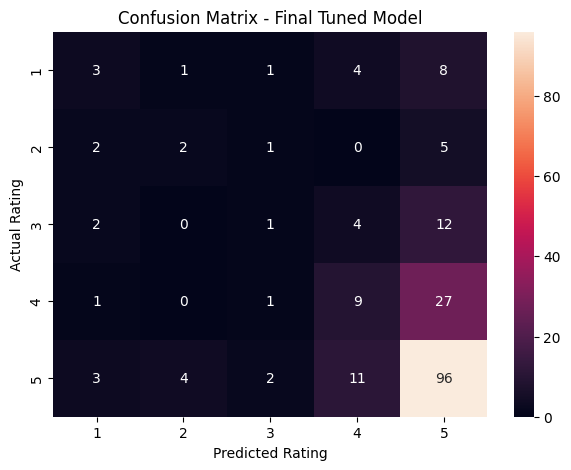

In [46]:
# Create the confusion matrix using predicted ratings
final_cm = confusion_matrix(
    y_test,
    final_pred,
    labels=[1, 2, 3, 4, 5]
)

# Plot the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

# Add labels and title
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix - Final Tuned Model")

# Display the plot
plt.show()

### 5.35 Classification Report

In [47]:
# Generate the classification report
print("Final Classification Report:")

print(classification_report(
    y_test,
    final_pred,
    labels=[1, 2, 3, 4, 5],
    zero_division=0
))

Final Classification Report:
              precision    recall  f1-score   support

           1       0.27      0.18      0.21        17
           2       0.29      0.20      0.24        10
           3       0.17      0.05      0.08        19
           4       0.32      0.24      0.27        38
           5       0.65      0.83      0.73       116

    accuracy                           0.56       200
   macro avg       0.34      0.30      0.31       200
weighted avg       0.49      0.56      0.51       200



The final model achieved 55.5% test accuracy. It performed best on the 5-star rating, with a precision of 0.65, recall of 0.83, and F1-score of 0.73. Performance on ratings 1–4 was considerably lower, particularly rating 3 with an F1-score of 0.08. The weighted F1-score was 0.51, while the macro F1-score was 0.31. These results show that the model is strongly influenced by the majority 5-star class and has difficulty distinguishing the less frequent rating classes.

## **Step 5.4: Conclusion and Future Improvements**

The neural network experiments showed that an MLP can classify Amazon review ratings, but its performance is limited by class imbalance and overfitting. The final tuned model used a **5000 → 64 → 5 architecture**, **ReLU activation**, the **Adam optimizer**, a **learning rate of 0.01**, **batch size of 16**, **20 epochs**, and **0.5 dropout**. The final model achieved a **best validation accuracy of 61.25%** and a **test accuracy of 55.5%**.

The model performed best on the majority **5-star class**, achieving **83% recall** and an **F1-score of 0.73**. However, performance on the lower rating classes was considerably weaker, with rating 3 achieving an **F1-score of 0.08**. The macro F1-score was **0.31**, compared with a weighted F1-score of **0.51**. These results show that the model is strongly influenced by the majority 5-star class and has difficulty distinguishing the less frequent rating classes.

### **Future Improvements**

* **Use early stopping:** Stop training when validation performance stops improving to reduce overfitting.

* **Apply L2 regularization:** Add regularization to reduce model complexity and improve generalization.

* **Use oversampling:** Increase the number of minority rating examples in the training data to reduce the effect of class imbalance.

* **Improve TF-IDF features:** Experiment with different `max_features`, n-gram ranges, and other TF-IDF settings.

* **Use word embeddings:** Explore Word2Vec or GloVe to represent relationships between words more effectively than TF-IDF.

* **Explore LSTM or GRU models:** Use recurrent neural networks to capture the sequence and context of words in reviews.

* **Explore transformer models:** Test models such as BERT to capture deeper contextual information from customer reviews.



